In [2]:
import os
import shutil

train_dir = 'D:/Major/AIProject/Recognition/RAF/train'
valid_dir = 'D:/Major/AIProject/Recognition/RAF/valid'
dataset_dir = 'D:/Major/AIProject/Recognition/dataset'

if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

for label in range(7): 
    label = str(label)
    label_dir = os.path.join(dataset_dir, label)
    if not os.path.exists(label_dir):
        os.makedirs(label_dir)

    train_label_dir = os.path.join(train_dir, label)
    if os.path.exists(train_label_dir):
        for img_file in os.listdir(train_label_dir):
            img_path = os.path.join(train_label_dir, img_file)
            shutil.move(img_path, os.path.join(label_dir, img_file))

    valid_label_dir = os.path.join(valid_dir, label)
    if os.path.exists(valid_label_dir):
        for img_file in os.listdir(valid_label_dir):
            img_path = os.path.join(valid_label_dir, img_file)
            shutil.move(img_path, os.path.join(label_dir, img_file))

print("数据集已合并完成！")


数据集已合并完成！


In [3]:
import os

dataset_dir = 'D:/Major/AIProject/Recognition/dataset'

for label in range(7): 
    label = str(label)
    label_dir = os.path.join(dataset_dir, label)
    
    if os.path.exists(label_dir):
        for idx, img_file in enumerate(os.listdir(label_dir)):
            new_file_name = f"img{label}_{idx:04d}.jpg"
            # 重命名文件
            os.rename(
                os.path.join(label_dir, img_file),
                os.path.join(label_dir, new_file_name)
            )

print("文件重命名完成！")

文件重命名完成！


In [4]:
from PIL import Image

dataset_dir = 'D:/Major/AIProject/Recognition/dataset'

for label in range(7):
    label_dir = os.path.join(dataset_dir, str(label))
    for img_file in os.listdir(label_dir):
        img_path = os.path.join(label_dir, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, SyntaxError) as e:
            print(f"发现损坏文件并删除: {img_path}")
            os.remove(img_path)


In [6]:
from PIL import Image

dataset_dir = 'D:/Major/AIProject/Recognition/dataset'   
target_size=(224, 224)

for label in range(7):
    label_dir = os.path.join(dataset_dir, str(label))
    for img_file in os.listdir(label_dir):
        img_path = os.path.join(label_dir, img_file)
        with Image.open(img_path) as img:
            img_resized = img.resize(target_size)
            img_resized.save(img_path)

print("图像尺寸标准化完成！")

图像尺寸标准化完成！


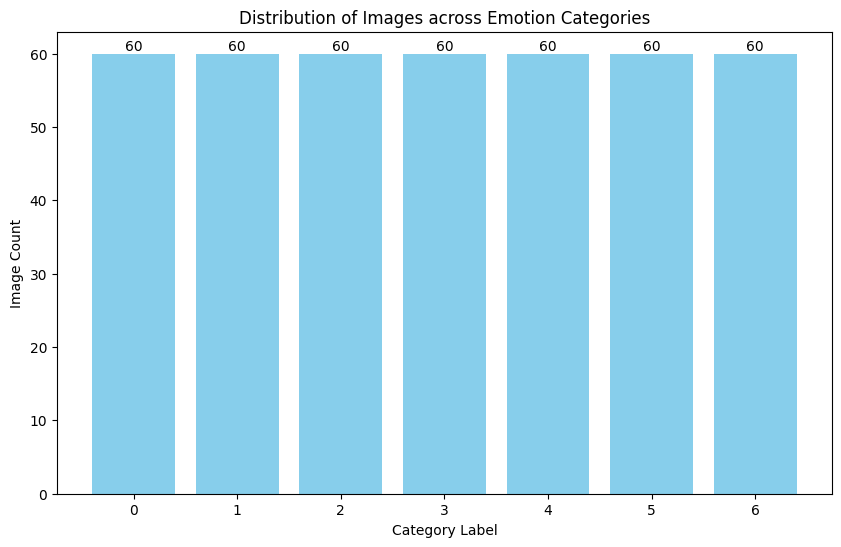

In [9]:
import os
import matplotlib.pyplot as plt
from collections import Counter

dataset_dir = 'D:/Major/AIProject/Recognition/dataset/test'  

label_counts = Counter()
for label in range(7):
    label_dir = os.path.join(dataset_dir, str(label))
    label_counts[label] = len(os.listdir(label_dir))

labels = list(label_counts.keys())
counts = list(label_counts.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color='skyblue')
plt.xlabel("Category Label")
plt.ylabel("Image Count")
plt.title("Distribution of Images across Emotion Categories")
plt.xticks(labels) 
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom')
plt.show()

In [10]:
import os
from PIL import Image
import random
from torchvision import transforms

augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),                   #以 50% 的概率随机水平翻转图像
    transforms.RandomRotation(15),                       #将图像随机旋转一个角度，旋转角度在-15到15度之间
    transforms.ColorJitter(brightness=0.2, contrast=0.2) #随机调整图像的亮度和对比度
])

def augment(dataset_dir, target_cnt, labels_to_augment):
    """
    为指定类别进行数据增强，直到样本数量达到目标数量。
    参数：
    - dataset_dir: 数据集的根目录
    - target_cnt: 每个类别的目标样本数量
    - labels_to_augment: 需要增加样本数量的类别标签列表
    """
    for label in labels_to_augment:
        label_dir = os.path.join(dataset_dir, str(label))
        images = os.listdir(label_dir)
        current_cnt = len(images)
        
        if current_cnt < target_cnt:
            print(f"正在增强类别 {label} 的样本数量，从 {current_cnt} 增加到 {target_cnt}...")
            # 随机选择图像进行增强
            for i in range(target_cnt - current_cnt):
                img_file = random.choice(images)
                img_path = os.path.join(label_dir, img_file)
                
                with Image.open(img_path) as img:
                    img_augmented = augmentation_transforms(img)
                    new_img_name = f"img{label}_{current_cnt + i}.jpg"
                    img_augmented.save(os.path.join(label_dir, new_img_name))
                    
            print(f"类别 {label} 增强完成，当前样本数量：{target_cnt}")

dataset_dir = 'D:/Major/AIProject/Recognition/dataset' 
target_cnt = 2460
labels_to_augment = [0, 1, 2, 5]

augment(dataset_dir, target_cnt, labels_to_augment)


正在增强类别 0 的样本数量，从 1619 增加到 2460...
类别 0 增强完成，当前样本数量：2460
正在增强类别 1 的样本数量，从 355 增加到 2460...
类别 1 增强完成，当前样本数量：2460
正在增强类别 2 的样本数量，从 877 增加到 2460...
类别 2 增强完成，当前样本数量：2460
正在增强类别 5 的样本数量，从 867 增加到 2460...
类别 5 增强完成，当前样本数量：2460


In [2]:
import os
import random

dataset_dir = 'D:/Major/AIProject/Recognition/dataset'
target_count = 2460

for category in ['3', '6']:
    category_path = os.path.join(dataset_dir, category)
    image_files = [f for f in os.listdir(category_path) if f.endswith('.jpg')]
    
    # 如果图片数量大于目标数量，则随机删除多余的图片
    if len(image_files) > target_count:
        images_to_delete = random.sample(image_files, len(image_files) - target_count)
        for img in images_to_delete:
            os.remove(os.path.join(category_path, img))
        print(f"已删除类别 {category} 中的 {len(images_to_delete)} 张图片，使其达到目标数量 {target_count}。")
    
    remaining_images = sorted([f for f in os.listdir(category_path) if f.endswith('.jpg')])
    for idx, img in enumerate(remaining_images):
        new_name = f"img{category}_{idx:04d}.jpg"
        os.rename(
            os.path.join(category_path, img),
            os.path.join(category_path, new_name)
        )
    print(f"已重新命名类别 {category} 中的图片。")
print("图片平衡与重命名完成！")


已删除类别 3 中的 3497 张图片，使其达到目标数量 2460。
已重新命名类别 3 中的图片。
已删除类别 6 中的 744 张图片，使其达到目标数量 2460。
已重新命名类别 6 中的图片。
图片平衡与重命名完成！
